In [ ]:
import pandas as pd
from sklearn.metrics import roc_auc_score

tile_file = "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/image_analysis/UCEC/pred_globalAS/tst_tile_pred.csv"

df = pd.read_csv(tile_file)

# aggregate tiles → patient
patient_df = (
    df.groupby("Patient_ID")
      .agg(label=("label","first"),
           Score_1=("Score_1","mean"))
      .reset_index()
)

print("Number of test patients:", len(patient_df))

auc = roc_auc_score(patient_df["label"], patient_df["Score_1"])
print("Patient-level AUROC:", auc)

Number of test patients: 9
Patient-level AUROC: 0.6666666666666666


In [ ]:
print(patient_df["Score_1"].nunique())
print(patient_df.sort_values("Score_1").head())
print(patient_df.sort_values("Score_1").tail())

9
     Patient_ID  label   Score_1
8  TCGA-EY-A1H0    1.0  0.025971
1  TCGA-B5-A11G    0.0  0.119683
2  TCGA-B5-A1MX    0.0  0.180543
6  TCGA-D1-A17D    0.0  0.192715
4  TCGA-BG-A18B    0.0  0.260070
     Patient_ID  label   Score_1
4  TCGA-BG-A18B    0.0  0.260070
3  TCGA-BG-A0VZ    0.0  0.273499
5  TCGA-D1-A176    0.0  0.320898
7  TCGA-EC-A1NJ    1.0  0.339682
0  TCGA-AP-A0LD    1.0  0.403550


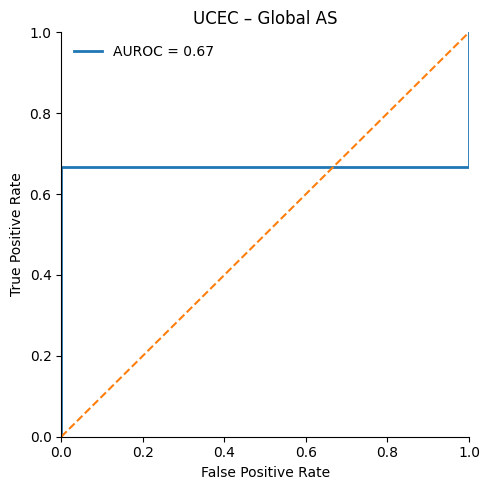

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(patient_df["label"], patient_df["Score_1"])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,5))

# STEP curve (important)
plt.step(fpr, tpr, where='post', linewidth=2, label=f"AUROC = {roc_auc:.2f}")

# diagonal
plt.plot([0,1], [0,1], linestyle="--")

plt.xlim([0,1])
plt.ylim([0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("UCEC – Global AS")

plt.legend(frameon=False)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("UCEC_globalAS_ROC.pdf", dpi=300)
plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import roc_auc_score

tile_file = "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/Annabel_Figure_codes/Figure 5 & S5/HNSC/pred_globalAS/tst_tile_pred.csv"

df = pd.read_csv(tile_file)

# aggregate tiles → patient
patient_df = (
    df.groupby("Patient_ID")
      .agg(label=("label","first"),
           Score_1=("Score_1","mean"))
      .reset_index()
)

print("Number of test patients:", len(patient_df))

auc = roc_auc_score(patient_df["label"], patient_df["Score_1"])
print("Patient-level AUROC:", auc)

Number of test patients: 29
Patient-level AUROC: 0.5571428571428572


Number of test patients: 29
Patient-level AUROC: 0.5571428571428572


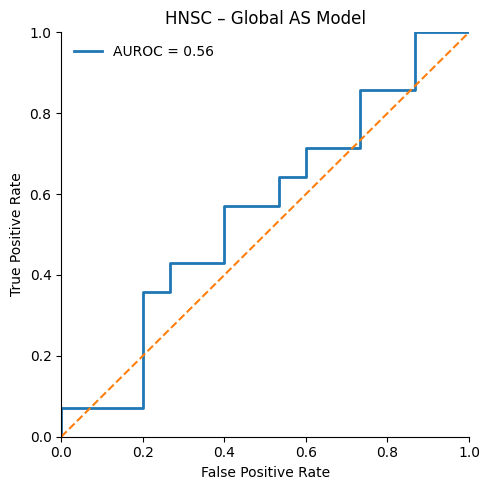

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, auc

# === load tile predictions ===
tile_file = "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/Annabel_Figure_codes/Figure 5 & S5/HNSC/pred_globalAS/tst_tile_pred.csv"

df = pd.read_csv(tile_file)

# === aggregate tiles → patient ===
patient_df = (
    df.groupby("Patient_ID")
      .agg(label=("label","first"),
           Score_1=("Score_1","mean"))
      .reset_index()
)

print("Number of test patients:", len(patient_df))

# === compute AUROC ===
roc_auc = roc_auc_score(patient_df["label"], patient_df["Score_1"])
print("Patient-level AUROC:", roc_auc)

# === ROC curve ===
fpr, tpr, _ = roc_curve(patient_df["label"], patient_df["Score_1"])

# === plot (publication style) ===
plt.figure(figsize=(5,5))

plt.step(fpr, tpr, where='post', linewidth=2,
         label=f"AUROC = {roc_auc:.2f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlim([0,1])
plt.ylim([0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("HNSC – Global AS Model")

plt.legend(frameon=False)

# clean style
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("HNSC_globalAS_ROC.pdf", dpi=300)
plt.show()

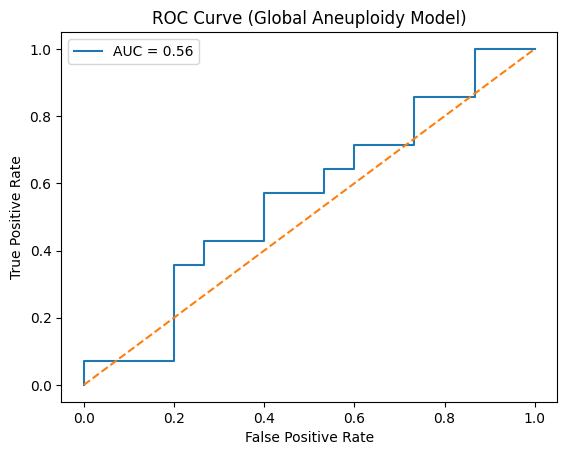

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# compute ROC
fpr, tpr, thresholds = roc_curve(patient_df["label"], patient_df["Score_1"])

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Global Aneuploidy Model)")
plt.legend()
plt.show()

In [ ]:
import pandas as pd
from scipy.stats import spearmanr

arm = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/image_analysis/HNSC.HPVneg/combined_HNSC_Arm9pLoss_labels.csv")
glob = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/image_analysis/HNSC.HPVneg/HNSC_HPVneg_globalAS_labels.csv")

df = pd.merge(arm, glob, on="Patient_ID")

print(df.head())
print("Number of patients:", len(df))

           Patient_ID Tumor_x  Arm_9p_Loss Tumor_y  Global_AS  High_Global_AS
0  TCGA-BA-4074-tumor    HNSC            1    HNSC         17               1
1  TCGA-BA-4075-tumor    HNSC            0    HNSC         28               1
2  TCGA-BA-4076-tumor    HNSC            1    HNSC         12               0
3  TCGA-BA-4078-tumor    HNSC            1    HNSC         19               1
4  TCGA-BA-5149-tumor    HNSC            0    HNSC         17               1
Number of patients: 343


In [ ]:
corr, p = spearmanr(df["Global_AS"], df["Arm_9p_Loss"])

print("Spearman correlation:", corr)
print("p-value:", p)

Spearman correlation: 0.2748561948877018
p-value: 2.318862228198265e-07


In [ ]:
import pandas as pd
from scipy.stats import spearmanr

# Load arm label file (1q gain)
arm = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/image_analysis/HNSC.HPVneg/combined_HNSC_Arm1qGain_labels.csv")

# Load global aneuploidy score
glob = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/image_analysis/HNSC.HPVneg/HNSC_HPVneg_globalAS_labels.csv")

# Merge by Patient_ID
df = pd.merge(arm, glob, on="Patient_ID")

print(df.head())
print("Number of patients:", len(df))

# Compute Spearman correlation
corr, p = spearmanr(df["Global_AS"], df["Arm_1q_Gain"])

print("Spearman correlation:", corr)
print("p-value:", p)

           Patient_ID Tumor_x  Arm_1q_Gain Tumor_y  Global_AS  High_Global_AS
0  TCGA-BA-4074-tumor    HNSC            0    HNSC         17               1
1  TCGA-BA-4075-tumor    HNSC            0    HNSC         28               1
2  TCGA-BA-4076-tumor    HNSC            0    HNSC         12               0
3  TCGA-BA-4078-tumor    HNSC            0    HNSC         19               1
4  TCGA-BA-5149-tumor    HNSC            0    HNSC         17               1
Number of patients: 343
Spearman correlation: 0.35613328549869616
p-value: 1.0779053469690004e-11


In [ ]:
import pandas as pd
from sklearn.metrics import roc_auc_score

tile_file = "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/image_analysis/UCEC/pred_globalAS/tst_tile_pred_comb.csv"

df = pd.read_csv(tile_file)

# aggregate tiles → patient
patient_df = (
    df.groupby("Patient_ID")
      .agg(label=("label","first"),
           Score_1=("Score_1","mean"))
      .reset_index()
)

print("Number of test patients:", len(patient_df))

auc = roc_auc_score(patient_df["label"], patient_df["Score_1"])
print("Patient-level AUROC:", auc)

Number of test patients: 11
Patient-level AUROC: 0.5


Updated codes to plot the clean-up version of the graphs 

UCEC – Global AS — N patients: 11
AUROC: 0.50


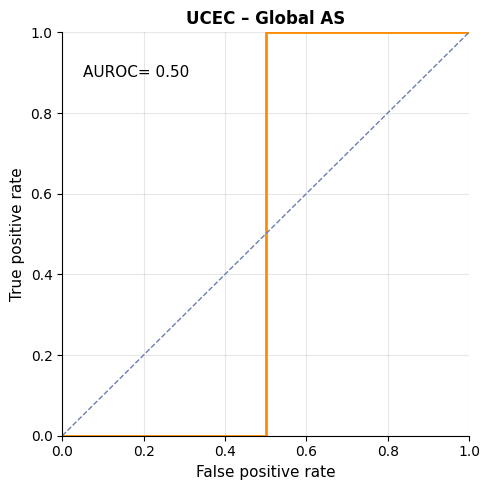

Saved: UCEC_globalAS_ROC.pdf

HNSC – Global AS — N patients: 29
AUROC: 0.56


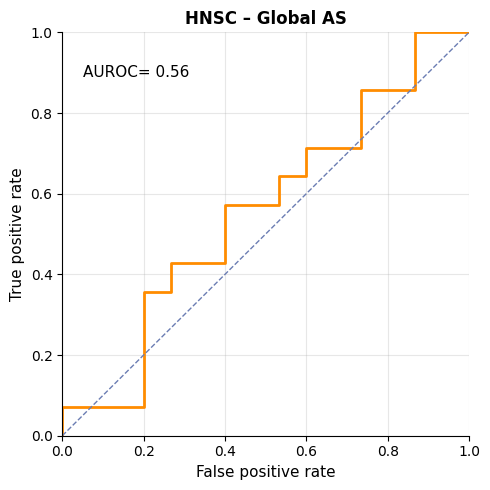

Saved: HNSC_globalAS_ROC.pdf



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, auc
import os

out_dir = "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/image_analysis/Global_AS"

# ── Define all models to plot ─────────────────────────────────────────────────
models = [
    {
        "title": "UCEC.MSI – Global AS",
        "file": "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/image_analysis/UCEC/pred_globalAS/tst_tile_pred.csv",
        "filename": "UCEC_globalAS_ROC.pdf"
    },
    {
        "title": "HNSC.HPVneg – Global AS",
        "file": "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/Annabel_Figure_codes/Figure 5 & S5/HNSC/pred_globalAS/tst_tile_pred.csv",
        "filename": "HNSC_globalAS_ROC.pdf"
    },
]

# ── Plot each model ───────────────────────────────────────────────────────────
for model in models:

    # Load and aggregate tiles to patient level
    df = pd.read_csv(model["file"])
    patient_df = (
        df.groupby("Patient_ID")
          .agg(label=("label", "first"),
               Score_1=("Score_1", "mean"))
          .reset_index()
    )

    print(f"{model['title']} — N patients: {len(patient_df)}")

    # Compute ROC
    fpr, tpr, _ = roc_curve(patient_df["label"], patient_df["Score_1"])
    roc_auc = auc(fpr, tpr)
    print(f"AUROC: {roc_auc:.2f}")

    # Plot — matching orange style from screenshot
    fig, ax = plt.subplots(figsize=(5, 5))

    ax.step(fpr, tpr, where='post', linewidth=2,
            color='#FF8C00',                          # orange like screenshot
            label=f"AUROC = {roc_auc:.2f}")

    ax.plot([0, 1], [0, 1], linestyle="--",
            color='#6B7DB3', linewidth=1)             # blue dashed diagonal

    # AUROC label on the LEFT like screenshot
    ax.text(0.05, 0.92,
            f"AUROC= {roc_auc:.2f}",
            transform=ax.transAxes,
            fontsize=11, color='black',
            verticalalignment='top')

    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_xlabel("False positive rate", fontsize=11)
    ax.set_ylabel("True positive rate", fontsize=11)
    ax.set_title(model['title'], fontsize=12, fontweight='bold')

    # Remove legend since AUROC is annotated directly
    ax.get_legend().remove() if ax.get_legend() else None

    # Clean style — remove top and right spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Add grid like screenshot
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, model["filename"]),
                format="pdf", bbox_inches="tight")
    plt.show()
    print(f"Saved: {model['filename']}\n")